# Information Retrieval Lab: Boolean Retrieval → Vector Space Model → TF‑IDF → BM25
In lab 1 we learnt different methods to calculating an index such as the **binary term-document matrix** and the **term-document count matrix**.

In this lab, we build one small document collection and progressively implement increasingly powerful retrieval models:

1. **Boolean retrieval**
2. **Vector Space Model (VSM)**
3. **TF‑IDF**  
4. **BM25**

---


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer


First things first.. we need to create a document index!

In [ ]:
# Documents to be indexed, similar to last time:
documents = ['Boats are great',
             'Sailing boats are environmental',
             'canal boats are often called narrow boats, they are quite environmental',
             'wooden boats are more work than metal boats',
             'wooden boats are more work than metal boats, but trawlers are the worst',
             'a wooden house is always the prettiest',
             'narrow cars fit through narrow streets and are environmental',
             'boats boats boats']

In [ ]:
vectorizer_bin = CountVectorizer(stop_words='english', binary=True)
term_doc_mat = vectorizer_bin.fit_transform(documents)
vocabulary = vectorizer_bin.get_feature_names_out()
vocabulary

In [ ]:
# let's just have a look what we have
term_doc_df_bin = pd.DataFrame(term_doc_mat.toarray(), columns=vocabulary)
term_doc_df_bin

In [ ]:
# dictionary that maps each term to the index of the documents its in.
term_occurence = {}
for i, term in enumerate(vocabulary):
  term_occurence[term] = np.where(term_doc_df_bin[term] == 1)[0].tolist()
term_occurence

# Boolean Retrieval Model

The **Boolean Retrieval Model** is a classical information retrieval model that operates on the principles of set theory. In this model, documents and queries are represented as sets of terms, and the retrieval process is based on Boolean operations such as AND, OR, and NOT. Each document and query is viewed as a binary vector, where each dimension represents the presence (1) or absence (0) of a specific term. The relevance of documents is determined by the Boolean operators applied to these vectors.



Lets first consider a Boolean retrieval model that handles **only simple 1 term queries**.

In [ ]:
def boolean_retrieval_simple(query, term_occurence):

    # Does the query term appear in the vocab
    if query in vocabulary:
      # Which docs does the query appear ?
      results = term_occurence[query]
    else:
      return print('Error: Query term "{}" is not in vocabulary'.format(query))

    return results

# Example simple query with no boolean operators: "environmental"
query = 'environmental'

# Perform boolean retrieval
result = boolean_retrieval_simple(query, term_occurence)

# Print the result
print('Documents matching the query: ')
if result == [] or result==None:
  print('No match')
else:
  for doc_id in result:
    print("Doc ID {}: {}".format(doc_id, documents[doc_id]))

However Boolean retrieval models use a **set of terms** as the query which are combined using Boolean operators AND, OR, and NOT.

In [ ]:
# First lets recap on how we can implement simple boolean operations in python.

x = set(['boats', 'wood', 'river'])
y = set(['canal', 'boats', 'water'])

# X or Y
print('X or Y: ', x.union(y))

# X and Y
print('X and Y: ', x.intersection(y))

# X and not Y.
print('X and not Y: ', x.difference(y))

# Y and not X.
print('Y and not X: ', y.difference(x))

Next lets explore a boolean retrieval model, which takes as input a set of queries which are combined using boolean operations, and our term ocurences dictionary. The model retrieves the documents that fit the boolean query.

For simplicity this code can only use the 'AND' boolean operator in its query.

In [ ]:
def boolean_retrieval_AND(query, term_occurence):
  # Initialize the result set with all documents
    results_list = []

    # Process the query
    for term in query:
        # Does the query term appear in the vocab
        if term in vocabulary:
          # Which doc does the query appear ?
          doc_idx = term_occurence[term]
          results_list.append(doc_idx) # append it to our results list
        else:
          return print('Error: Query term "{}" is not in vocabulary'.format(term))

    # Find the intersection between all the documents that contain query terms.
    # '*' (astrix) allows us to accept a list of any length (i.e any number of query terms is possible)
    result = set(results_list[0]).intersection(*results_list[1:])

    return list(result)

# Example boolean query: "boats AND environmental"
query = ['boats', 'environmental']

# Perform boolean retrieval
result = boolean_retrieval_AND(query, term_occurence)

# Print the result
print('Documents matching the query: ')
if result == [] or result==None:
  print('No match')
else:
  for doc_id in result:
    print("Doc ID {}: {}".format(doc_id, documents[doc_id]))

Task: What about a Boolean model that uses the 'OR' operator. Complete the function with your own code

In [ ]:
def boolean_retrieval_OR(query, term_occurence):
  # Initialize the result set with all documents
    results_list = []

    # Process the query
    for term in query:
        if term in vocabulary:
          doc_idx = term_occurence[term]
          results_list.append(doc_idx)
        else:
          return print('Error: term "{}" is not in vocabulary'.format(term))

    # your code goes here
    result =

    return list(result)

# Example boolean query: "metal OR environment"
query = ['metal', 'environmental']

# Perform boolean retrieval
result = boolean_retrieval_OR(query, term_occurence)

# Print the result
print('Documents matching the query: ')
if result == []:
  print('No match')
for doc_id in result:
  print("Doc ID {}: {}".format(doc_id, documents[doc_id]))

What about including the boolean operator 'Not'?

For simplicity, lets consider only AND and NOT boolean queries, for example: **'boats' AND NOT 'environmental'** or **NOT 'streets' AND 'boats**

This one is a little harder.. Here are some hints
* set().difference may be useful here.
* To input the 'NOT' operator, one option would be to include it at the begin of a query term. e.g 'NOTboats'

Make sure you test your function with lots of inputs. Is the output what you expected?

In [ ]:
def boolean_retrieval_AND_NOT(query, term_occurence):

    # your code goes here

    return list(result)

# Example boolean query: "boats AND NOT environmental"
query = ['boats', 'NOTenvironmental']

# Perform boolean retrieval
result = boolean_retrieval_AND_NOT(query, term_occurence)

# Print the result
print('Documents matching the query: ')
if result == [] or result==None:
  print('No match')
else:
  for doc_id in result:
    print("Doc ID {}: {}".format(doc_id, documents[doc_id]))

## Vector Space Model

The Vector Space Model (VSM) is a widely used information retrieval model that represents documents and queries as vectors in a multi-dimensional space. In VSM, each term is associated with a dimension, and the weight of a term in a document is proportional to its importance. The relevance of documents to a query is measured based on the similarity of their vectors in this space.

**How do we represent documents and queries as vectors?** Well..we have actually done so already using the binary term-document matrix and the term-document count matrix. The typical approach is using **Tf-IDF** but we'll save that for next week.


In [ ]:
# e.g of document vectors

term_doc_mat_np = term_doc_mat.toarray()

d2_vector = term_doc_mat_np[1,:]
print('Doc 2: ', d2_vector)

d4_vector = term_doc_mat_np[3,:]
print('Doc 4: ', d4_vector)



In [ ]:
# similar process applies for queries..

def create_query_vector(query, vocabulary):

    # create empty query vector
    query_vector = np.zeros_like(vocabulary)

    # iterate through query terms
    for term in query:
        # if query term is in vocab, then find its position in the vocab array.
        # update the query vector in that position with a 1.
        if term in vocabulary:
            vocab_idx = np.where(vocabulary == term)[0][0]
            query_vector[vocab_idx] = 1
        else:
            print('Error: term "{}" is not in vocabulary'.format(term))

    return query_vector

query = ['boats', 'metal', 'wooden']

query_vector = create_query_vector(query, vocabulary)

print('Query vector: ', query_vector)


**How is similarity measured?** The cosine similarity is used as a measure of how similar two vectors are, and is defnied as follows:


$\text{Cosine Similarity}(\mathbf{d}, \mathbf{q}) = \frac{\mathbf{d} \cdot \mathbf{q}}{\|\mathbf{d}\| \cdot \|\mathbf{q}\|}$

Where d is a document vector and q is a query vector. The output is a score between 0 and 1.

**Task**: Complete the code below for the cosine similarity function

In [ ]:
def cosine_similarity(vector1, vector2):

    # numerator = the dot product between d and q
    numerator = # your code goes here
    # denominator = the magnitude of d multiplied by the magnitude of q
    denominator = # your code goes here

    return numerator / denominator

d2q_similarity = cosine_similarity(d2_vector, query_vector)
print('Cosine similarity between d2 and query: ', d2q_similarity)

d4q_similarity = cosine_similarity(d4_vector, query_vector)
print('Cosine similarity between d4 and query: ', d4q_similarity)



**Question**: Are the outputs what you expected given what you know about docs 2 and 4?

Lets put all the parts together to create the vector space model

In [ ]:
def vector_space_model(term_doc_mat_np, query):
  query_vector = create_query_vector(query, vocabulary)

  results = []

  # iterate through all documents
  for doc_idx, doc_vector in enumerate(term_doc_mat_np):
      # calculate the relevance score between doc and query
      relevance_score = cosine_similarity(doc_vector, query_vector)
      results.append([doc_idx, relevance_score, documents[doc_idx]])

  return results

query = ['narrow', 'boats']

results = vector_space_model(term_doc_mat_np, query)

print('Documents sorted by relevance to query:')
results = sorted(results, key=lambda x: x[1], reverse=True)
for res in results:
  print('Doc ID {}, Relevance Score: {:.3f}, Doc: {}'.format(*res))

**Question**: What is different between the output of the boolean retrieval model and the vector space model?

One is ranked with relevance scores, the other is binary (relevance or not relevant)

**Question**: What do you observe in the ranking of the documents? Is there anything that is surprising? Give two observations.

- Longer documents are penalised.
- Documents with repeated works are not given more weight

**Question**: What about if we use the term-document count matrix instead of the binary term-document matrix? Have a think about what changes you expect to see in the ranking of documents. Next, write code to perform vector space retrieval using the count matrix. (You may need to adapt some functions)

##  TF‑IDF
---

In [ ]:
# For ranking models (TF‑IDF / BM25) we usually need **counts** (not just binary presence).
vectorizer_count = CountVectorizer(stop_words='english')  # counts
documents_vectorized = vectorizer_count.fit_transform(documents)
vocabulary_count = vectorizer_count.get_feature_names_out()


In [ ]:
# term-document count matrix as a dataframe (docs x terms)
dataframe = pd.DataFrame(documents_vectorized.toarray(), columns=vocabulary_count)
dataframe

## TF-IDF

TF-IDF is an acronym for term frequency - inverse document frequency. It is used to evaluate the importance of a term in a document relative to the collection of documents. It improves on term frequency (TF) as it considers how unique and significant a word is across a corpus (collection of documents).

Let's break down TF-IDF into its components:

1. **Term Frequency (TF):** This component measures how frequently a term appears in a document. It is calculated by counting the occurrences of a term in a document and normalizing it by the total number of terms in the document. *This is the same as the term-document count matrices we have previously calculated, but the values are normalised.*

   $\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$

2. **Inverse Document Frequency (IDF):** This component measures the uniqueness or importance of a term across a collection of documents. It is calculated by dividing the total number of documents in the corpus by the number of documents containing the term, and taking the logarithm of the result. This helps in giving higher weights to terms that are rare and, thus, more informative.

   $\text{IDF}(t, D) = \log\left(\frac{\text{Total number of documents in corpus } D}{\text{Number of documents containing term } t}\right)$

We can then define **TF-IDF Score:** as follows:

$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$



The intuition behind TF-IDF is that it rewards terms that are frequent within a document but rare across the entire corpus. This helps in distinguishing important terms from common terms. Terms like "the," "and," or "is" are likely to have high term frequencies but low TF-IDF scores due to their prevalence across many documents.

In [ ]:
# lets start with finding the TF scores for every term-document combination.
tfs = dataframe.div(dataframe.sum(axis=1), axis=0)
tfs

In [ ]:
# now lets calculate the IDF for every term in the dataset:

# first get the document frequency DF (i.e. how many documents does each phrase appear in?):
# this should be an array of size (N,) where N is the number of terms in the vocabulary.
dfs = # ... your code goes here
print(dfs.shape, dfs)

# then calculate idf:
idfs = # ... your code goes here
print(idfs.shape, idfs)

In [ ]:
# tf-idf
tf_idf = # .... your code goes here.
tf_idf

## BM25

TF-IDF weights can be used in many models such as the Vector Space Model (VSM), Binary Independence Model (BIM) and the Divergence From Randomness (DFR).

In the BM25 model, TF-IDF is used in combination with other other statistical measures such as the document length ($dl$), average document length ($avdl$), and tuning parameters ($k_{1}$ and $b$). We'll touch on the intuition behind those later..

These can be combined in various ways, and has led to many different implementations of BM25. We'll use the formula below which is a simplified version of the one in the slides:


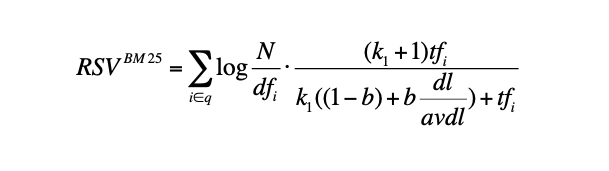

In [ ]:
# Next let's get have a look at the term frequencies and turn them into BM25 term frequencies.

# Let's first define all the variables we need:
k_1 = 1.2  # single value (default)
b = 0.8  # single value (default)
dls = # .... your code goes here  (array of size N where N is the number of documents)
avgdl = # .... your code goes here  (single value)

print(k_1, b, dls, avgdl)


In [ ]:
# With these we can calculate the BM25 term frequency quantification. Switching to numpy to make things easier:
numerator = np.array((k_1 + 1) * tfs)
denominator = # ... your code goes here

BM25_tf = numerator / denominator

BM25_score = idfs * BM25_tf

In [ ]:
bm25_dataframe = pd.DataFrame(BM25_score, columns=vocabulary)
bm25_dataframe

So here we have the BM25 scores for each documents. But how? We don't even have a query yet?!

Since the query terms are independent we can calculate the BM25 weight for each term in each document already. When we get a query we only consider terms that appear in the query, as is clear from the equation

This is super important concept in information retrieval, as it means that the index can be pre-computed. Ever wondered how Google can return search results in 0.05 seconds? Well its because the computationally intensive process of creating an index has already been done in advance. Querying a matrix is typically a very fast process.

In [ ]:
# let's say we have the query "wooden boats":
q_terms = ['wooden', 'boats']

In [ ]:
# How would you find documents that fit the query well based on the BM25 score?:
# hint: start by cutting up bm25_df in terms of the query terms
q_terms_only_df = bm25_dataframe[q_terms]
print(q_terms_only_df)

# see equation above
score_q_d = q_terms_only_df.sum(axis=1)
print(score_q_d)

In [ ]:
# rank the documents
ranked_docs = sorted(zip(enumerate(documents), score_q_d.values),
                     key = lambda tup:tup[1],
                     reverse=True)
for doc in ranked_docs:
  print(f'Score: {doc[1]:.4f}, Document {doc[0][0]}: "{doc[0][1]}"')

### Question 1:

For our query ('wooden', 'boats'), what is your intuition as to why BM25 would rank document 3 above document 4?

**d3** = 'wooden boats are more work than metal boats'

**d4** = 'wooden boats are more work than metal boats, but trawlers are the worst'

A: longer documents are penalised more by the $dl / avdg$ term.

### Question 2:

For our query ('wooden', 'boats'), what is your intuition as to why BM25 would rank document 7 above document 4?

**d7** = 'boats boats boats'

**d4** = 'wooden boats are more work than metal boats, but trawlers are the worst'

A: 'wooden' is the rarer word than 'boats' so it receives a higher IDF score, however this is counteracted by the length of the d4 which far longer than d7, hence the value of dl/avdl will be larger. The fact that 'boats' is repeated 3 times in d7 means that the term frequency will be higher. Parameters k1 and b can be used to tune the term saturation and impact of document length.

### Question 3:

Are there any results in the retrieval of documents that you think are surprising, or wrong? Remember no retrieval model is perfect and each has its own limitations.

A: There are many possible answers here.
One example is that document 4 appears quite far down the list, despite having the high IDF scoring query term 'wooden'.
Another example is that document 7 is high scoring but does not contain 'wooden' (high scoring IDF term). It contains the term 'boats' (lower scoring IDF) tem, but this is counteracted by its term frequency and document length.

### Question 4:

We mentioned that BM25 has tunable parameters $k_{1}$ and $b$. Describe the purpose of $k_{1}$ and $b$? How could they be tuned to change the ranking of documents in Question 1 and Question 2.  

A:

If b is bigger, the effects of the length of the document compared to the average length are more amplified. If b = 0, then the length of a document would not contribute to the BM25 score. If b = 0 in Question 1, then document d3 and d4 would have the same score. Larger values of b would increase the difference in scores between d3 and d4.  

k1 is a variable which helps determine term frequency saturation characteristics. That is, it limits how much a single query term can affect the score of a given document. When $k_{1}$ increases, repeated terms are likely to have larger weights. In Question 2, if $k_{1}$ decreased then the score of d0 would also decrease, as the term frequency of 'boats' would become more saturated.

This is a really good resource to answer learn more about $k_{1}$ and $b$

https://www.elastic.co/blog/practical-bm25-part-2-the-bm25-algorithm-and-its-variables